In [1]:
# Use Chatgpt/Copilot for debug purpose

In [2]:
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
# read csv file contains labels of each image
import pandas as pd

# df = pd.read_csv(r"E:\TT_exported\all_labels.csv")
df = pd.read_csv("path/to/all_labels.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'path/to/all_labels.csv'

In [5]:
df_test = df[df["split"].str.startswith("test")].copy()
df_test.head()

,index,label,lr_path,hr_path,split
0,1,QU04029757,E:\TT_exported\test\easy\lr\000000001.png,E:\TT_exported\test\easy\hr\000000001.png,test\easy
1,2,QU04029757,E:\TT_exported\test\easy\lr\000000002.png,E:\TT_exported\test\easy\hr\000000002.png,test\easy
2,3,(Camille,E:\TT_exported\test\easy\lr\000000003.png,E:\TT_exported\test\easy\hr\000000003.png,test\easy
3,4,Moses,E:\TT_exported\test\easy\lr\000000004.png,E:\TT_exported\test\easy\hr\000000004.png,test\easy
4,5,Impressionist,E:\TT_exported\test\easy\lr\000000005.png,E:\TT_exported\test\easy\hr\000000005.png,test\easy


In [6]:
df_test_medium = df[df["split"] == r"test\medium"].copy()
df_test_medium.head()

,index,label,lr_path,hr_path,split
2962,1,Quickly,E:\TT_exported\test\medium\lr\000000001.png,E:\TT_exported\test\medium\hr\000000001.png,test\medium
2963,2,thur,E:\TT_exported\test\medium\lr\000000002.png,E:\TT_exported\test\medium\hr\000000002.png,test\medium
2964,3,fri,E:\TT_exported\test\medium\lr\000000003.png,E:\TT_exported\test\medium\hr\000000003.png,test\medium
2965,4,11:00am-11:00,E:\TT_exported\test\medium\lr\000000004.png,E:\TT_exported\test\medium\hr\000000004.png,test\medium
2966,5,sat,E:\TT_exported\test\medium\lr\000000005.png,E:\TT_exported\test\medium\hr\000000005.png,test\medium


In [7]:
import re

# normalize text 
# 1. to lower case 
# 2.remove any character that is not a lowercase letter or digit
def normalize_text(text):
    text_lowered = str(text).lower()                
    text_lowered = re.sub(r"[^a-z0-9]", "", text_lowered)   
    return text_lowered

In [1]:
from pathlib import Path
import sys
# Register the model directory in Python’s search path



CRNN_REPO = Path("path/to/crnn")
ASTER_REPO = Path("path/to/aster")
MORAN_REPO = Path("path/to/moran")



# CRNN_REPO = Path(r"E:\TT_exported\crnn.pytorch-master")
if str(CRNN_REPO) not in sys.path:
    sys.path.append(str(CRNN_REPO))

# ASTER_REPO = Path(r"E:\TT_exported\aster.pytorch-master")  
if str(ASTER_REPO) not in sys.path:
    sys.path.append(str(ASTER_REPO))

# MORAN_REPO = Path(r"E:\TT_exported\MORAN_v2-master")
if str(ASTER_REPO) not in sys.path:
    sys.path.append(str(MORAN_REPO))

In [9]:
import torch
# use GPU to run 
device = torch.device("cuda")


In [10]:
import numpy as np

# CRNN

In [11]:
import utils
import dataset
import models.crnn as crnn
from PIL import Image
from scipy.stats import gmean

In [12]:
# defining CRNN parameters
# plus one for CTC
apt = "0123456789abcdefghijklmnopqrstuvwxyz"
n = len(apt) + 1
model = crnn.CRNN(32, 1, n, 256)

# load crnn weight
crnn_w = torch.load(
    CRNN_REPO / "data" / "crnn.pth",
    map_location = "cpu",
    weights_only = False
)
model.load_state_dict(crnn_w)
model = model.to(device)
model.eval()

print("CRNN loaded successful on", device)

CRNN loaded successful on cuda


In [13]:
normalize = dataset.resizeNormalize((100, 32))

# convert to text
crnn_converter = utils.strLabelConverter("0123456789abcdefghijklmnopqrstuvwxyz")


def predict_crnn(path):
    # into grayscale and on gpu
    img = Image.open(path).convert("L")
    img = normalize(img)
    img = img.view(1, *img.size())
    img = img.to(device)

    with torch.no_grad():
        # Getting scores for each time step, tensor shape [time steps, batch size, score]
        log = model(img)
        p = torch.softmax(log, dim = 2)
        max_p, max_idx = p.max(2)

        pred_idx = max_idx[:, 0].cpu()
        pred_size = torch.IntTensor([pred_idx.numel()])

        pred_text = crnn_converter.decode(pred_idx, pred_size, raw = False)
        raw_text = crnn_converter.decode(pred_idx, pred_size, raw = True)

        # a proxy for word level confidence
        idx_list = max_idx[:, 0].cpu().tolist()
        p_list = max_p[:, 0].cpu().tolist()
        result_p = []
        prev = None

        # keep prob of non blank, non repeated characters after CTC collapse
        for idx, p in zip(idx_list, p_list):
            if idx != 0 and idx != prev:   # blank = 0, repeat collapse
                result_p.append(float(p))
            prev = idx

        # keep probs for char showed in desired apt
        pred_chars = list(pred_text)
        if len(pred_chars) != len(result_p):
            min_len = min(len(pred_chars), len(result_p))
            pred_chars = pred_chars[:min_len]
            result_p = result_p[:min_len]
            
        filtered_p = []
        for ch, p in zip(pred_chars, result_p):
            ch = str(ch).lower()
            if re.fullmatch(r"[a-z0-9]", ch):
                filtered_p.append(float(p))
        result_p = filtered_p 
        
        # calculate confidence by using geometric mean
        if result_p:
            conf = float(gmean(np.clip(result_p, 1e-12, 1.0)))
        else:
            conf = 0.0

    return pred_text, conf, raw_text

In [14]:
# result as a dataframe
result = df_test_medium["lr_path"].apply(predict_crnn)
df_test_medium[["pred_text", "confidence", "raw_text"]] = pd.DataFrame(
    result.tolist(),
    index = df_test_medium.index
)

df_test_medium["correct"] = (df_test_medium["pred_text"] == df_test_medium["label"]).astype(int)
df_test_medium.head()

,index,label,lr_path,hr_path,split,pred_text,confidence,raw_text,correct
2962,1,Quickly,E:\TT_exported\test\medium\lr\000000001.png,E:\TT_exported\test\medium\hr\000000001.png,test\medium,saky,0.484269,s-------a------k-----y----,0
2963,2,thur,E:\TT_exported\test\medium\lr\000000002.png,E:\TT_exported\test\medium\hr\000000002.png,test\medium,unur,0.898969,u-------n-----u------r----,0
2964,3,fri,E:\TT_exported\test\medium\lr\000000003.png,E:\TT_exported\test\medium\hr\000000003.png,test\medium,tri,0.558624,t------------r-----ii-----,0
2965,4,11:00am-11:00,E:\TT_exported\test\medium\lr\000000004.png,E:\TT_exported\test\medium\hr\000000004.png,test\medium,arodamenroo,0.590347,a--r-o-d-a--m--e-n--r-o-o-,0
2966,5,sat,E:\TT_exported\test\medium\lr\000000005.png,E:\TT_exported\test\medium\hr\000000005.png,test\medium,sat,0.999944,ss----------a--------t----,1


In [15]:
# since alphabet used in each models are different, this step aim to normalize the text with a common alphabet
df_test_medium["label_n"] = df_test_medium["label"].apply(normalize_text)
df_test_medium["pred_n"]  = df_test_medium["pred_text"].apply(normalize_text)
df_test_medium["correct_n"] = (df_test_medium["label_n"] == df_test_medium["pred_n"]).astype(int)

## CRNN Diagram

In [16]:
def calibration_table(y_true, y_p, n_bin):
    
    # y_true: iscorrect
    # y_p: confidence
    # n_bin: score bin

    # to numpy array as float
    y_true = np.asarray(y_true).astype(float)
    y_p = np.asarray(y_p).astype(float)

    # remove all null entries
    mask = ~np.isnan(y_true) & ~np.isnan(y_p)
    y_true = y_true[mask]
    y_p = y_p[mask]

    # in case p outside [0,1]
    y_p = np.clip(y_p, 0, 1)

    # constructng bin edge
    bin_edge = np.linspace(0, 1, n_bin + 1)
    # allocating sample p to correct bin
    bin_ids = np.digitize(y_p, bin_edge[1:-1], right = True)

    rows = []
    n = len(y_true)

    for i in range(n_bin):
        is_inbin = bin_ids == i
        count = is_inbin.sum()

        if count > 0:
            bin_acc = y_true[is_inbin].mean()
            bin_conf = y_p[is_inbin].mean()
            bin_f = count / n
            
        else:
            bin_acc = np.nan
            bin_conf = np.nan
            bin_f = 0.0

        rows.append({
            "bin": i,
            "count": count,
            "fraction": bin_f,
            "accuracy": bin_acc,
            "avg_confidence": bin_conf,
            "abs_gap": np.nan if count == 0 else abs(bin_acc - bin_conf)
        })

    table = pd.DataFrame(rows)

    # ECE: weighted avg |acc - conf|
    ece = (table["fraction"] * table["abs_gap"].fillna(0)).sum()

    # Brier score: avg mean square error
    brier = np.mean((y_p - y_true) ** 2)

    return table, ece, brier

In [17]:
def plot_reliability_diagram(table):
    plot_df = table[table["count"] > 0].copy()

    plt.figure(figsize = ( 6, 6))
    plt.plot([0, 1], [0, 1], linestyle = "--")
    plt.bar(
        plot_df["avg_confidence"],
        plot_df["accuracy"],
        width = 1 / len(table) * 0.9,
        alpha = 0.7
    )
    
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Confidence")
    plt.ylabel("Empirical Accuracy")
    plt.title("Reliability Diagram")
    plt.grid(True, linestyle = "--", alpha = 0.5)
    plt.show()

In [18]:
word_acc = df_test_medium["correct_n"].mean()
print("word accuracy =", word_acc)

word accuracy = 0.20552799433026223


In [19]:
df_test_medium.groupby("correct_n")["confidence"].mean()

correct_n
0    0.523279
1    0.933557
Name: confidence, dtype: float64

In [20]:
table, ece, brier = calibration_table(
    y_true = df_test_medium["correct_n"],
    y_p = df_test_medium["confidence"],
    n_bin = 10
)

print("ECE =", ece)
print("Brier score =", brier)

table

ECE = 0.40207439897826347
Brier score = 0.2738939300534012


,bin,count,fraction,accuracy,avg_confidence,abs_gap
0,0,16,0.011339,0.000000,0.011633,0.011633
1,1,74,0.052445,0.000000,0.161472,0.161472
2,2,178,0.126152,0.005618,0.255553,0.249935
3,3,176,0.124734,0.011364,0.349385,0.338022
4,4,146,0.103473,0.027397,0.450615,0.423218
5,5,119,0.084337,0.058824,0.548412,0.489588
6,6,113,0.080085,0.053097,0.645333,0.592235
7,7,107,0.075833,0.093458,0.750945,0.657487
8,8,131,0.092842,0.206107,0.852025,0.645918
9,9,351,0.248760,0.663818,0.975133,0.311316


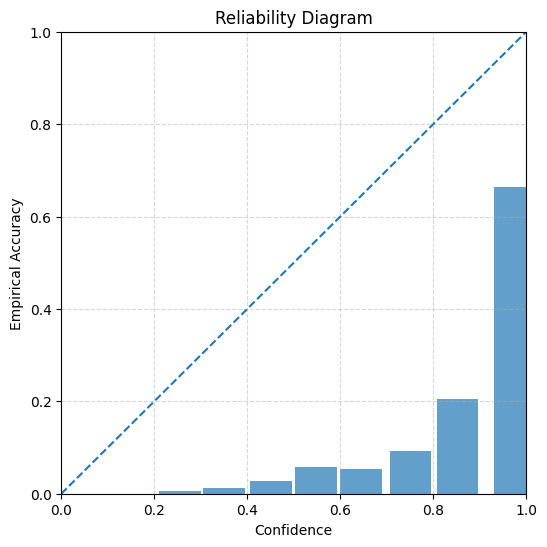

In [21]:
plot_reliability_diagram(table)

In [22]:
overconfident_errors = df_test_medium[
    (df_test_medium["correct_n"] == 0) & (df_test_medium["confidence"] >= 0.8)
].copy()

overconfident_errors[["index", "label_n", "pred_n", "confidence", "lr_path"]].head(20)

,index,label_n,pred_n,confidence,lr_path
2963,2,thur,unur,0.898969,E:\TT_exported\test\medium\lr\000000002.png
2969,8,california,califormia,0.944581,E:\TT_exported\test\medium\lr\000000008.png
2971,10,milk,mox,0.827274,E:\TT_exported\test\medium\lr\000000010.png
2976,15,added,aadra,0.820306,E:\TT_exported\test\medium\lr\000000015.png
2977,16,the,ihc,0.915844,E:\TT_exported\test\medium\lr\000000016.png
3002,41,behind,ochino,0.837682,E:\TT_exported\test\medium\lr\000000041.png
3005,44,pounded,counded,0.926012,E:\TT_exported\test\medium\lr\000000044.png
3021,60,waffle,wallic,0.922485,E:\TT_exported\test\medium\lr\000000060.png
3023,62,but,oul,0.934277,E:\TT_exported\test\medium\lr\000000062.png
3026,65,bike,bar,0.984185,E:\TT_exported\test\medium\lr\000000065.png


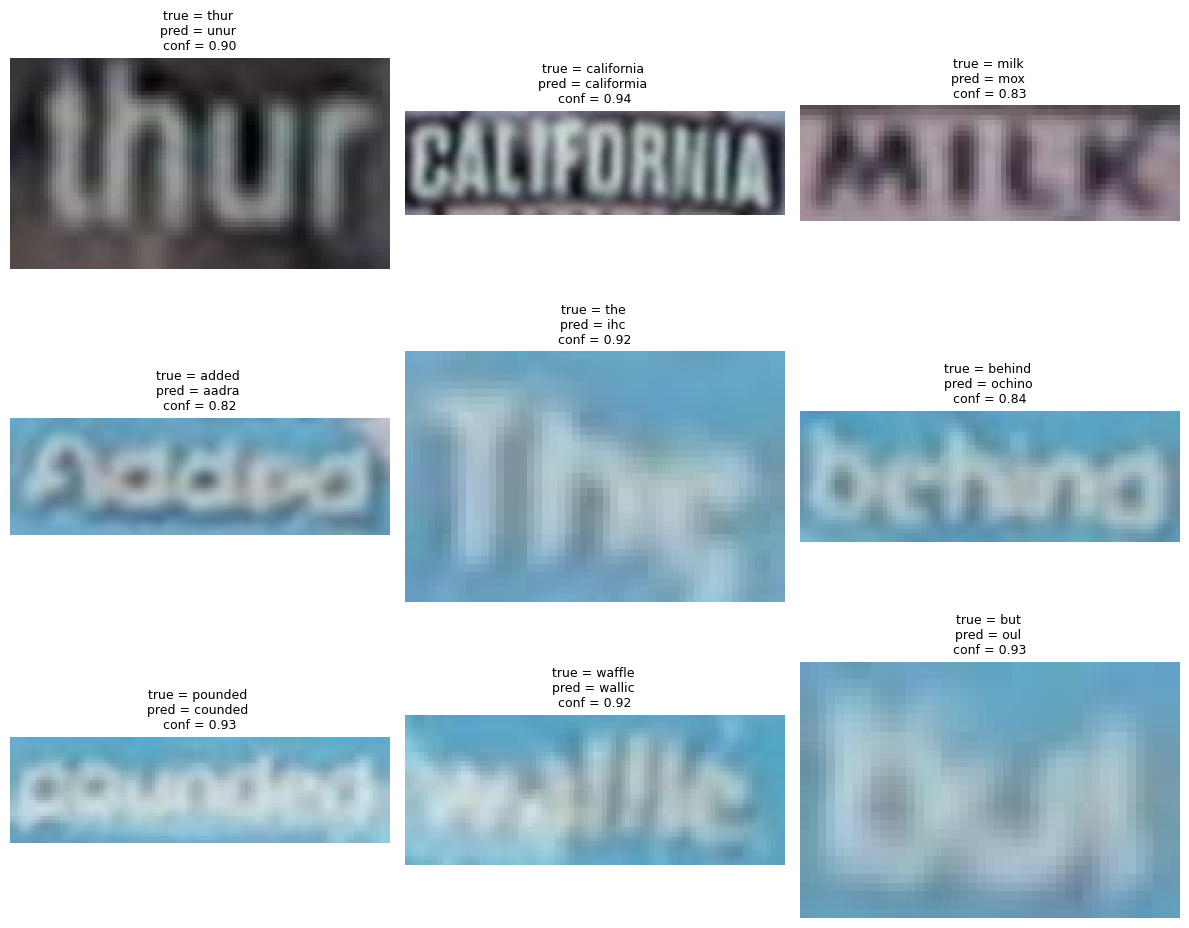

In [23]:
from PIL import Image

sample_err = overconfident_errors.head(9)

plt.figure(figsize = (12, 10))
for i, (_, row) in enumerate(sample_err.iterrows(), 1):
    img = Image.open(row["lr_path"])
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(
        f'true = {row["label_n"]} \npred = {row["pred_n"]} \nconf = {row["confidence"]:.2f}',
        fontsize = 9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# ASTER

In [24]:
import torch.nn.functional as F
import os
import sys
from torchvision import transforms
import types
import torch
from PIL import Image

os.chdir(ASTER_REPO)
sys.argv = [sys.argv[0], "--with_lstm"]

In [25]:
from lib.models.model_builder import ModelBuilder
from lib.utils.labelmaps import get_vocabulary

In [26]:
# Helper functions
class DataInfo:
      def __init__(self, voc_type = "ALLCASES_SYMBOLS"):
        # special token use by the decoder
        self.EOS = "EOS"
        self.PADDING = "PADDING"
        self.UNKNOWN = "UNKNOWN"

        # append special token require by the decoder
        self.voc = get_vocabulary(
            voc_type,
            EOS = self.EOS,
            PADDING = self.PADDING,
            UNKNOWN = self.UNKNOWN
        )

        # map between char and class index
        self.char2id = dict(zip(self.voc, range(len(self.voc))))
        self.id2char = dict(zip(range(len(self.voc)), self.voc))
        self.rec_num_classes = len(self.voc)

In [27]:
data_info = DataInfo("ALLCASES_SYMBOLS")

aster = ModelBuilder(
    arch = "ResNet_ASTER",
    rec_num_classes = data_info.rec_num_classes,
    sDim = 512,
    attDim = 512,
    max_len_labels = 100,
    eos = data_info.char2id[data_info.EOS],
    STN_ON = True
)

aster_w = torch.load(
    ASTER_REPO  / "data" / "demo.pth", 
    map_location = "cpu", 
    weights_only = False)

# depending on checkpoint format:
if "state_dict" in aster_w:
    aster.load_state_dict(aster_w["state_dict"])
else:
    aster.load_state_dict(aster_w)

aster = aster.to(device)
aster.eval()

print("ASTER loaded successfully on", device)

ASTER loaded successfully on cuda


In [28]:
TPS_INPUTSIZE = (32, 64)


def image_process(path, H = 32, W = 100):
    # read image, resize, convert to tensor, normalize to [-1, 1]
    img = Image.open(path).convert("RGB")
    img = img.resize((W, H), Image.BILINEAR)
    img = transforms.ToTensor()(img)
    img.sub_(0.5).div_(0.5)
    return img


@torch.no_grad()
def sample_cuda_safe(self, x):
    # keep all new tensor on the same device as encoder feature
    batch_size = x.size(0)
    dev = x.device
    state = torch.zeros(1, batch_size, self.sDim, device = dev)

    pred_idx = []
    max_p = []

    for i in range(self.max_len_labels):
        # first step uses BOS token
        if i == 0:
            y_prev = torch.full((batch_size,), self.num_classes, dtype = torch.long, device = dev)
        else:
            y_prev = pred.long().to(dev)

        output, state = self.decoder(x, state, y_prev)
        p = F.softmax(output, dim = 1)
        p_max, pred = p.max(1)

        pred_idx.append(pred.unsqueeze(1))
        max_p.append(p_max.unsqueeze(1))

    pred_idx = torch.cat(pred_idx, dim = 1)
    max_p = torch.cat(max_p, dim = 1)

    return pred_idx, max_p


# patch decoder with CUDA safe greedy decoding
aster.decoder.sample = types.MethodType(sample_cuda_safe, aster.decoder)


@torch.no_grad()
def aster_forward_n(model, img):
    x = img

    # rectify image with STN / TPS before recognition
    if model.STN_ON:
        stn_input = F.interpolate(x, TPS_INPUTSIZE,mode = "bilinear", align_corners = True)
        _, ctrl_point = model.stn_head(stn_input)
        x, _ = model.tps(x, ctrl_point)

    # extract visual sequence feature
    encoder_feat = model.encoder(x).contiguous()

    # greedy decode on encoder feature
    pred_idx, max_p = model.decoder.sample(encoder_feat)

    return pred_idx, max_p


def predict_aster(path):
    img = image_process(path, H = 32, W = 100)
    img = img.unsqueeze(0).to(device)

    eos_id = data_info.char2id[data_info.EOS]
    pad_id = data_info.char2id[data_info.PADDING]
    unk_id = data_info.char2id[data_info.UNKNOWN]

    with torch.no_grad():
        pred_idx, max_p = aster_forward_n(aster, img)
        
        pred_idx = pred_idx[0].detach().cpu().tolist()
        p_list = max_p[0].detach().cpu().tolist()

        char = []
        raw_token = []
        result_p = []

        for idx, p in zip(pred_idx, p_list):
            idx = int(idx)
            ch = data_info.id2char.get(idx, "")

            raw_token.append(ch)

            # stop at EOS
            if idx == eos_id:
                break

            # skip padding
            if idx == pad_id:
                continue

            # map unknown token to '?'
            if idx == unk_id:
                char.append("?")
            else:
                char.append(ch)

            result_p.append(float(p))

        pred_text = "".join(char)
        raw_text = " | ".join(raw_token)

        pred_chars = list(pred_text)
        if len(pred_chars) != len(result_p):
            min_len = min(len(pred_chars), len(result_p))
            pred_chars = pred_chars[:min_len]
            result_p = result_p[:min_len]

        filtered_p = []
        for ch, p in zip(pred_chars, result_p):
            ch = str(ch).lower()
            if re.fullmatch(r"[a-z0-9]", ch):
                filtered_p.append(float(p))
        result_p = filtered_p 
        
        # calculate confidence by using geometric mean
        if result_p:
            conf = float(gmean(np.clip(result_p, 1e-12, 1.0)))
        else:
            conf = 0.0

    return pred_text, conf, raw_text

In [29]:
df_test_medium_aster = df[df["split"] == r"test\medium"].copy()

In [30]:
result = df_test_medium_aster["lr_path"].apply(predict_aster)

df_test_medium_aster[["pred_text", "confidence", "raw_text"]] = pd.DataFrame(
    result.tolist(),
    index = df_test_medium_aster.index
)

df_test_medium_aster["correct"] = (
    df_test_medium_aster["pred_text"] == df_test_medium_aster["label"]
).astype(int)

df_test_medium_aster.head()

C:\Users\Eric Zhang\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


,index,label,lr_path,hr_path,split,pred_text,confidence,raw_text,correct
2962,1,Quickly,E:\TT_exported\test\medium\lr\000000001.png,E:\TT_exported\test\medium\hr\000000001.png,test\medium,the,0.368150,t | h | e | EOS,0
2963,2,thur,E:\TT_exported\test\medium\lr\000000002.png,E:\TT_exported\test\medium\hr\000000002.png,test\medium,thur,0.999109,t | h | u | r | EOS,1
2964,3,fri,E:\TT_exported\test\medium\lr\000000003.png,E:\TT_exported\test\medium\hr\000000003.png,test\medium,(ri,0.977651,( | r | i | EOS,0
2965,4,11:00am-11:00,E:\TT_exported\test\medium\lr\000000004.png,E:\TT_exported\test\medium\hr\000000004.png,test\medium,11:00:27-71100,0.724168,1 | 1 | : | 0 | 0 | : | 2 | 7 | - | 7 | 1 | 1 ...,0
2966,5,sat,E:\TT_exported\test\medium\lr\000000005.png,E:\TT_exported\test\medium\hr\000000005.png,test\medium,sat,0.997959,s | a | t | EOS,1


In [31]:
df_test_medium_aster["label_n"] = df_test_medium_aster["label"].apply(normalize_text)
df_test_medium_aster["pred_n"] = df_test_medium_aster["pred_text"].apply(normalize_text)

df_test_medium_aster["correct_n"] = (
    df_test_medium_aster["label_n"] == df_test_medium_aster["pred_n"]
).astype(int)

## ASTER DIAGRAM

In [32]:
word_acc = df_test_medium_aster["correct_n"].mean()
print("word accuracy =", word_acc)


word accuracy = 0.41105598866052445


In [33]:
df_test_medium_aster.groupby("correct_n")["confidence"].mean()

correct_n
0    0.540480
1    0.927608
Name: confidence, dtype: float64

In [34]:
table, ece, brier = calibration_table(
    y_true = df_test_medium_aster["correct_n"],
    y_p = df_test_medium_aster["confidence"],
    n_bin = 10
)

print("ECE =", ece)
print("Brier score =", brier)

table

ECE = 0.2898644038636652
Brier score = 0.21696175405134122


,bin,count,fraction,accuracy,avg_confidence,abs_gap
0,0,58,0.041106,0.017241,0.001316,0.015926
1,1,27,0.019135,0.000000,0.161043,0.161043
2,2,45,0.031892,0.044444,0.253683,0.209238
3,3,89,0.063076,0.022472,0.355998,0.333526
4,4,133,0.094259,0.052632,0.448328,0.395697
5,5,152,0.107725,0.039474,0.544918,0.505445
6,6,126,0.089298,0.142857,0.650616,0.507759
7,7,134,0.094968,0.194030,0.749665,0.555636
8,8,138,0.097803,0.521739,0.855577,0.333838
9,9,509,0.360737,0.876228,0.975775,0.099547


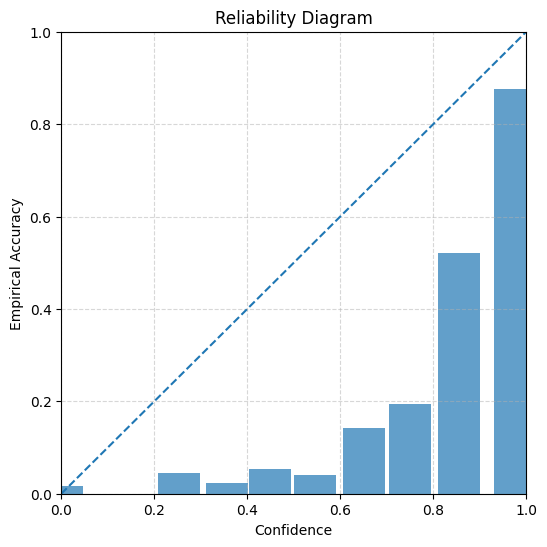

In [35]:
plot_reliability_diagram(table)

In [36]:
overconfident_errors = df_test_medium_aster[
    (df_test_medium_aster["correct_n"] == 0) & (df_test_medium_aster["confidence"] >= 0.8)
].copy()

overconfident_errors[["index", "label_n", "pred_n", "confidence", "lr_path"]].head(20)

,index,label_n,pred_n,confidence,lr_path
2964,3,fri,ri,0.977651,E:\TT_exported\test\medium\lr\000000003.png
2969,8,california,califorma,0.925395,E:\TT_exported\test\medium\lr\000000008.png
2983,22,rice,the,0.874591,E:\TT_exported\test\medium\lr\000000022.png
3016,55,just,you,0.904941,E:\TT_exported\test\medium\lr\000000055.png
3018,57,like,the,0.984603,E:\TT_exported\test\medium\lr\000000057.png
3021,60,waffle,wallie,0.865216,E:\TT_exported\test\medium\lr\000000060.png
3026,65,bike,bar,0.812728,E:\TT_exported\test\medium\lr\000000065.png
3027,66,bike,but,0.866294,E:\TT_exported\test\medium\lr\000000066.png
3030,69,enough,snough,0.944911,E:\TT_exported\test\medium\lr\000000069.png
3038,77,differenec,diffrence,0.873663,E:\TT_exported\test\medium\lr\000000077.png


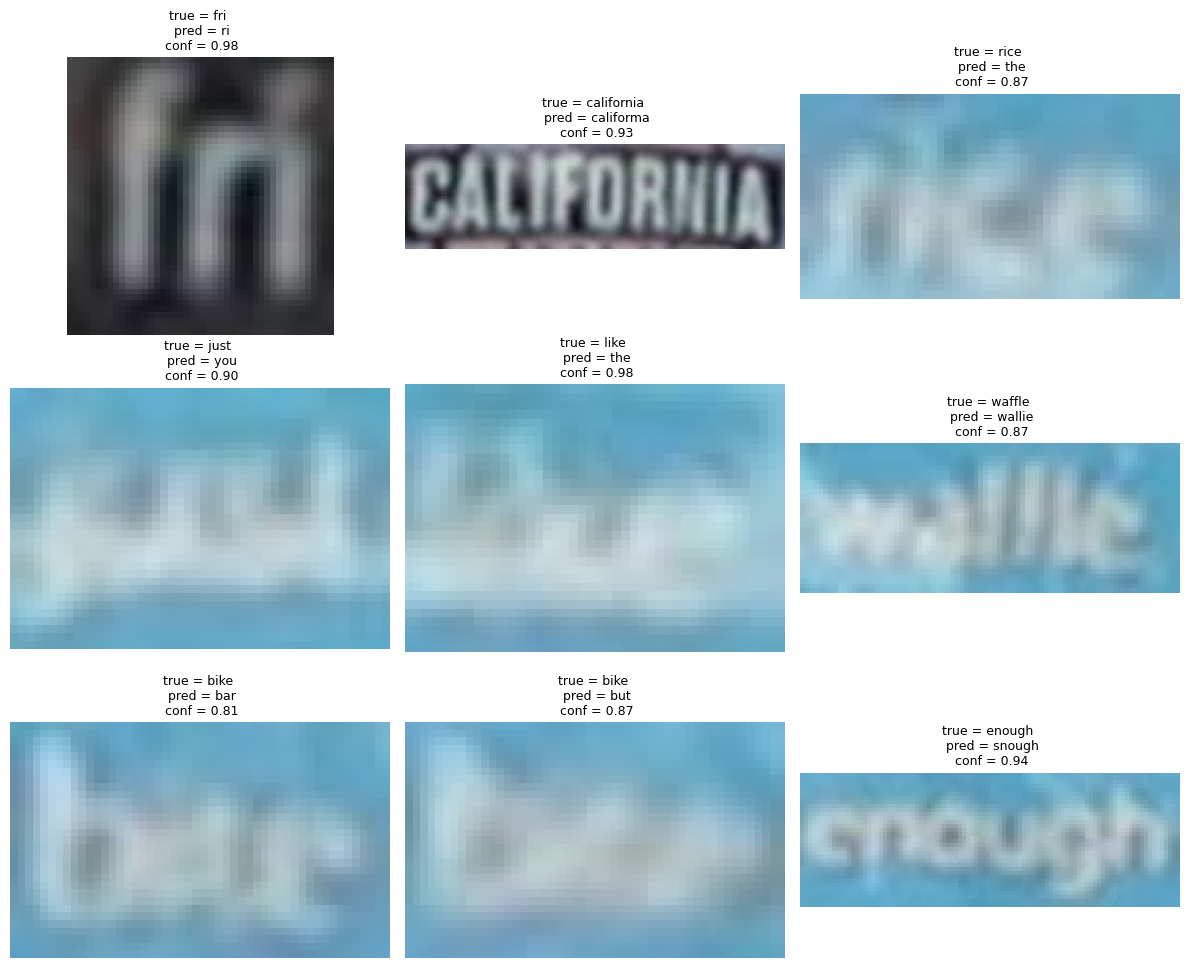

In [37]:
from PIL import Image

sample_err = overconfident_errors.head(9)

plt.figure(figsize = (12, 10))
for i, (_, row) in enumerate(sample_err.iterrows(), 1):
    img = Image.open(row["lr_path"])
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(
        f'true = {row["label_n"]} \n pred = {row["pred_n"]}\n conf = {row["confidence"]:.2f}',
        fontsize = 9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# Moran

In [38]:
print(os.listdir(os.path.join(MORAN_REPO, "models")))

['asrn_res.py', 'fracPickup.py', 'moran.py', 'morn.py', '__init__.py', '__pycache__']


In [39]:
import os
import sys
import importlib
from collections import OrderedDict

os.chdir(MORAN_REPO)

if MORAN_REPO not in sys.path:
    sys.path.insert(0, MORAN_REPO)

if "models" in sys.modules:
    del sys.modules["models"]

moran_utils = importlib.import_module("tools.utils")
moran_dataset = importlib.import_module("tools.dataset")
MORAN = importlib.import_module("models.moran").MORAN

In [40]:
apt = "0:1:2:3:4:5:6:7:8:9:a:b:c:d:e:f:g:h:i:j:k:l:m:n:o:p:q:r:s:t:u:v:w:x:y:z:$"
n = len(apt.split(":"))

moran_model = MORAN(1, n, 256, 32, 100, BidirDecoder = True, CUDA = True)

state_dict = torch.load(
    MORAN_REPO / "demo" / "demo.pth",
    map_location = "cpu",
    weights_only = False
)

state_dict_rename = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")
    state_dict_rename[name] = v

moran_model.load_state_dict(state_dict_rename)
moran_model = moran_model.to(device)
moran_model.eval()

for p in moran_model.parameters():
    p.requires_grad = False


moran_converter = moran_utils.strLabelConverterForAttention(apt, ":")
normalize = moran_dataset.resizeNormalize((100, 32))

print("MORAN loaded on", device)

C:\Users\Eric Zhang\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
E:\TT_exported\MORAN_v2-master\models\asrn_res.py:234: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  nn.init.kaiming_normal(m.weight, mode='fan_out', a=0)
E:\TT_exported\MORAN_v2-master\models\asrn_res.py:236: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  nn.init.constant(m.weight, 1)
E:\TT_exported\MORAN_v2-master\models\asrn_res.py:237: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  nn.init.constant(m.bias, 0)


MORAN loaded on cuda


In [41]:
@torch.no_grad()
def predict_moran(path, max_iter = 20):
    # into grayscale and on gpu
    img = Image.open(path).convert("L")
    img = normalize(img)
    img = img.view(1, *img.size()).to(device)

    text = torch.LongTensor(1 * 5)
    length = torch.IntTensor(1)

    t, l = moran_converter.encode("0" * max_iter)
    utils.loadData(text, t)
    utils.loadData(length, l)

    text = text.to(device)
    length = length.to(device)

    # debug = False for normal inference
    pred = moran_model(img, length, text, text, test = True, debug = False)

    # test = True and BidirDecoder = True -> (preds_ltr, preds_rtl)
    pred_ltr, pred_rtl = pred

    log = pred_ltr
    p = F.softmax(log, dim = 1)
    max_p, max_idx = p.max(1)

    raw_text = moran_converter.decode(max_idx.data, length.data)
    pred_text = raw_text.strip().split("$")[0]

    raw_seq = raw_text.strip()
    eos_pos = raw_seq.find("$")

    if eos_pos == -1:
        result_p = max_p[ : len(raw_seq)]
    else:
        result_p = max_p[ : eos_pos + 1]

    result_p = result_p.detach().cpu().numpy()

    pred_chars = list(pred_text)
    if len(pred_chars) != len(result_p):
        min_len = min(len(pred_chars), len(result_p))
        pred_chars = pred_chars[:min_len]
        result_p = result_p[:min_len]
        
    filtered_p = []
    for ch, p in zip(pred_chars, result_p):
        ch = str(ch).lower()
        if re.fullmatch(r"[a-z0-9]", ch):
            filtered_p.append(float(p))
    result_p = filtered_p 

    # calculate confidence by using geometric mean
    if len(result_p) > 0:
        conf = float(gmean(np.clip(result_p, 1e-12, 1.0)))
    else:
        conf = 0.0

    return pred_text, conf, raw_text

In [42]:
df_test_medium_moran = df[df["split"] == r"test\medium"].copy()

result = df_test_medium_moran["lr_path"].apply(predict_moran)

df_test_medium_moran[["pred_text", "confidence", "raw_text"]] = pd.DataFrame(
    result.tolist(),
    index = df_test_medium_moran.index
)

df_test_medium_moran["correct"] = (
    df_test_medium_moran["pred_text"] == df_test_medium_moran["label"]
).astype(int)

df_test_medium_moran.head()

E:\TT_exported\MORAN_v2-master\models\morn.py:59: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x_small = nn.functional.upsample(x, size=(self.targetH, self.targetW), mode='bilinear')
C:\Users\Eric Zhang\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


,index,label,lr_path,hr_path,split,pred_text,confidence,raw_text,correct
2962,1,Quickly,E:\TT_exported\test\medium\lr\000000001.png,E:\TT_exported\test\medium\hr\000000001.png,test\medium,sendy,0.561929,sendy$$$$y$e$y$y$y$y,0
2963,2,thur,E:\TT_exported\test\medium\lr\000000002.png,E:\TT_exported\test\medium\hr\000000002.png,test\medium,thur,0.974468,thur$$$$$$$$$$$$$$$$,1
2964,3,fri,E:\TT_exported\test\medium\lr\000000003.png,E:\TT_exported\test\medium\hr\000000003.png,test\medium,fri,0.998413,fri$$$$$$$$$$$$$$$$$,1
2965,4,11:00am-11:00,E:\TT_exported\test\medium\lr\000000004.png,E:\TT_exported\test\medium\hr\000000004.png,test\medium,11004m11100,0.733917,11004m11100$$$$$$014,0
2966,5,sat,E:\TT_exported\test\medium\lr\000000005.png,E:\TT_exported\test\medium\hr\000000005.png,test\medium,sat,0.999985,sat$$$$$$$$$$$$$$$$$,1


In [43]:
df_test_medium_moran["label_n"] = df_test_medium_moran["label"].apply(normalize_text)
df_test_medium_moran["pred_n"]  = df_test_medium_moran["pred_text"].apply(normalize_text)

df_test_medium_moran["correct_n"] = (
    df_test_medium_moran["label_n"] == df_test_medium_moran["pred_n"]
).astype(int)

## Moran Diagram

In [44]:
word_acc = df_test_medium_moran["correct_n"].mean()
print("word accuracy =", word_acc)

df_test_medium_moran.groupby("correct")["confidence"].mean()

word accuracy = 0.3664068036853296


correct
0    0.665391
1    0.930389
Name: confidence, dtype: float64

In [45]:
table_moran, ece_moran, brier_moran = calibration_table(
    y_true = df_test_medium_moran["correct_n"],
    y_p = df_test_medium_moran["confidence"],
    n_bin = 10
)

print("ECE =", ece_moran)
print("Brier score =", brier_moran)

table_moran

ECE = 0.3416164707878239
Brier score = 0.2334138531603446


,bin,count,fraction,accuracy,avg_confidence,abs_gap
0,0,2,0.001417,0.000000,0.087233,0.087233
1,1,14,0.009922,0.000000,0.159603,0.159603
2,2,68,0.048193,0.000000,0.257439,0.257439
3,3,133,0.094259,0.007519,0.355384,0.347865
4,4,172,0.121899,0.005814,0.449571,0.443757
5,5,142,0.100638,0.028169,0.551994,0.523825
6,6,125,0.088590,0.104000,0.648166,0.544166
7,7,135,0.095677,0.133333,0.751456,0.618123
8,8,115,0.081502,0.356522,0.850441,0.493919
9,9,505,0.357902,0.869307,0.981906,0.112599


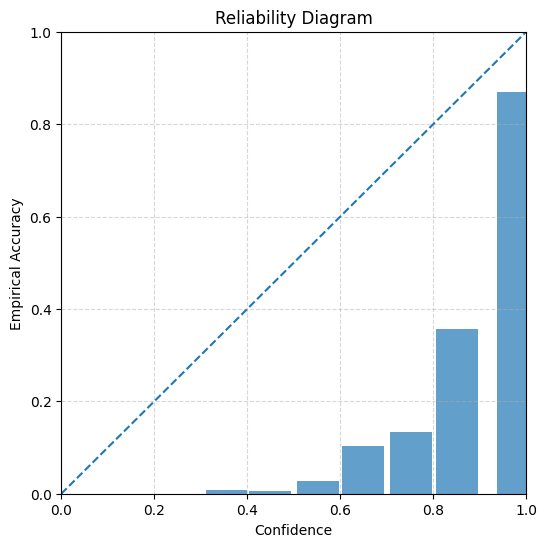

In [46]:
plot_reliability_diagram(table_moran)

In [47]:
overconfident_errors_moran = df_test_medium_moran[
    (df_test_medium_moran["correct"] == 0) &
    (df_test_medium_moran["confidence"] >= 0.8)
].copy()

overconfident_errors_moran[
    ["label_n", "pred_n", "confidence", "lr_path"]
].head(20)

,label_n,pred_n,confidence,lr_path
2969,california,califorma,0.948230,E:\TT_exported\test\medium\lr\000000008.png
2971,milk,milk,0.956219,E:\TT_exported\test\medium\lr\000000010.png
2972,no,no,0.998417,E:\TT_exported\test\medium\lr\000000011.png
2973,no,no,0.999179,E:\TT_exported\test\medium\lr\000000012.png
2974,water,water,0.993602,E:\TT_exported\test\medium\lr\000000013.png
2977,the,the,0.999318,E:\TT_exported\test\medium\lr\000000016.png
2978,the,the,0.967364,E:\TT_exported\test\medium\lr\000000017.png
2983,rice,like,0.857565,E:\TT_exported\test\medium\lr\000000022.png
2986,japanese,japanese,0.976356,E:\TT_exported\test\medium\lr\000000025.png
2988,have,bave,0.959805,E:\TT_exported\test\medium\lr\000000027.png


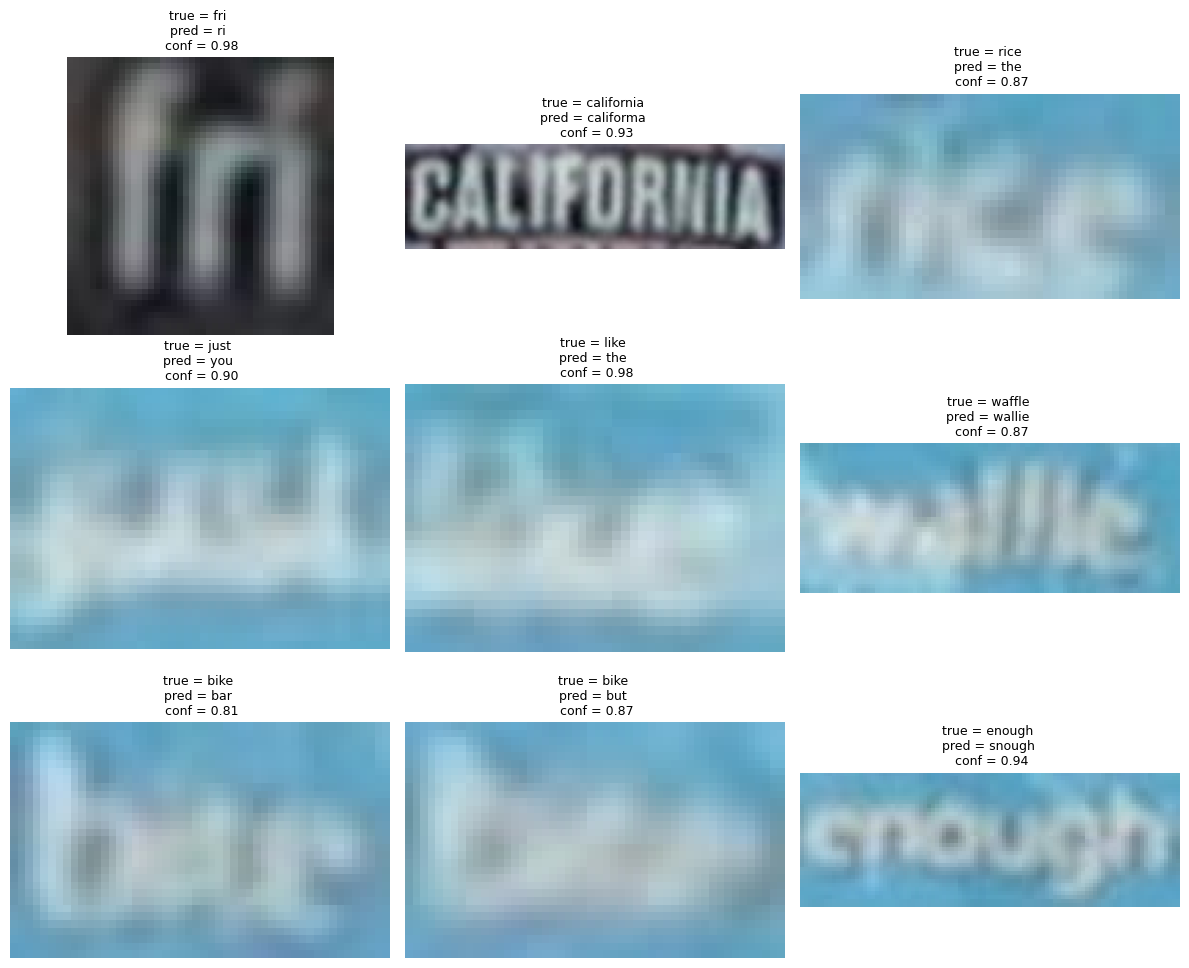

In [48]:
from PIL import Image

sample_err = overconfident_errors.head(9)

plt.figure(figsize = (12, 10))
for i, (_, row) in enumerate(sample_err.iterrows(), 1):
    img = Image.open(row["lr_path"])
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(
        f'true = {row["label_n"]} \npred = {row["pred_n"]} \n conf = {row["confidence"]:.2f}',
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# Analysis

In [49]:
def build_model_summary(df, model_name, correct_n_col = "correct_n", conf_col = "confidence", conf_threshold = 0.8):
    table, ece, brier = calibration_table(y_true = df[correct_n_col], y_p = df[conf_col], n_bin = 10)

    summary = {
        "model": model_name,
        "n": len(df),
        "word_acc": df[correct_n_col].mean(),
        "avg_conf": df[conf_col].mean(),
        "ECE": ece,
        "Brier": brier,
        "high_conf_wrong_rate": ((df[correct_n_col] == 0) & (df[conf_col] >= conf_threshold)).mean(),
        "high_conf_wrong_n": ((df[correct_n_col] == 0) & (df[conf_col] >= conf_threshold)).sum(),
        "wrong_avg_conf": df.loc[df[correct_n_col] == 0, conf_col].mean(),
        "correct_avg_conf": df.loc[df[correct_n_col] == 1, conf_col].mean(),
    }
    
    return summary, table


summary_crnn, table_crnn = build_model_summary(df_test_medium, "CRNN", correct_n_col = "correct_n")
summary_aster, table_aster = build_model_summary(df_test_medium_aster, "ASTER", correct_n_col = "correct_n")
summary_moran, table_moran = build_model_summary(df_test_medium_moran, "MORAN", correct_n_col = "correct_n")

summary_df = pd.DataFrame([summary_crnn, summary_aster, summary_moran])
summary_df

,model,n,word_acc,avg_conf,ECE,Brier,high_conf_wrong_rate,high_conf_wrong_n,wrong_avg_conf,correct_avg_conf
0,CRNN,1411,0.205528,0.607602,0.402074,0.273894,0.157335,222,0.523279,0.933557
1,ASTER,1411,0.411056,0.699611,0.289864,0.216962,0.091425,129,0.540480,0.927608
2,MORAN,1411,0.366407,0.708023,0.341616,0.233414,0.099220,140,0.565297,0.954827


In [50]:
def plot_metric_bar(summary_df, metric, title = None, sort_ascending = None):
    plot = summary_df.copy()

    if sort_ascending is not None:
        plot = plot.sort_values(metric, ascending = sort_ascending)

    plt.figure(figsize = (6, 6))
    bars = plt.bar(plot["model"], plot[metric])

    plt.ylabel(metric)
    plt.title(title)
    
    plt.grid(axis = "y", linestyle = "--", alpha = 0.5)

    for b, v in zip(bars, plot[metric]):
        plt.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f"{v:.4f}",
            ha = "center",
            va = "bottom",
            fontsize = 9
        )

    plt.show()

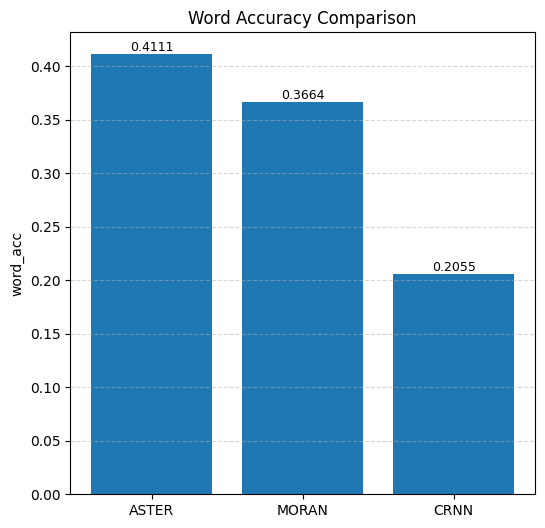

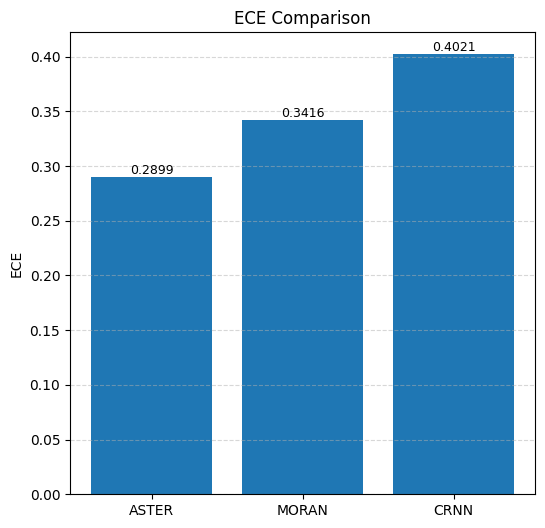

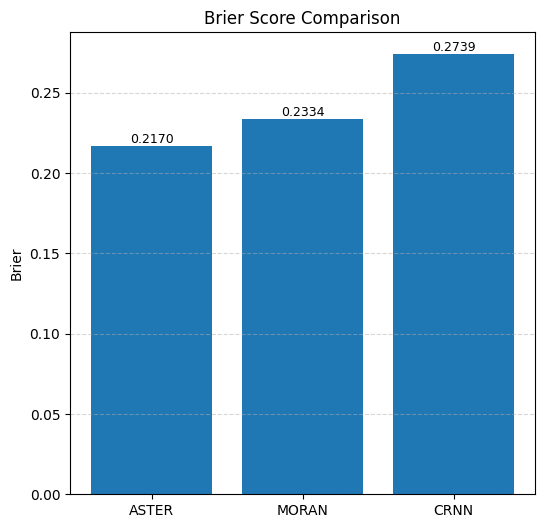

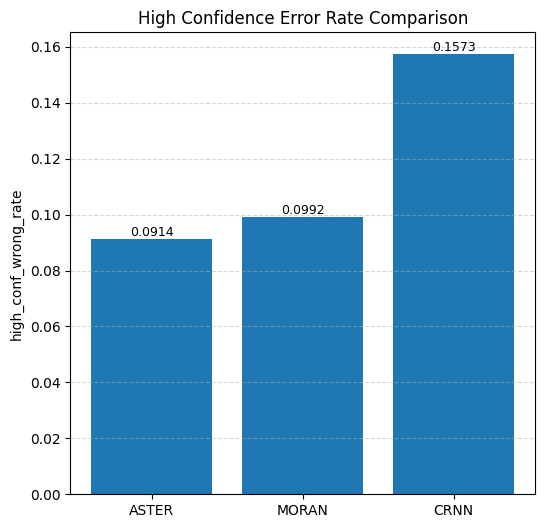

In [51]:
plot_metric_bar(summary_df, "word_acc", title = "Word Accuracy Comparison", sort_ascending = False)
plot_metric_bar(summary_df, "ECE", title = "ECE Comparison", sort_ascending = True)
plot_metric_bar(summary_df, "Brier", title = "Brier Score Comparison", sort_ascending = True)
plot_metric_bar(summary_df, "high_conf_wrong_rate", title = "High Confidence Error Rate Comparison", sort_ascending = True)

In [52]:
summary_df[["model", "high_conf_wrong_rate", "high_conf_wrong_n", "n"]]

,model,high_conf_wrong_rate,high_conf_wrong_n,n
0,CRNN,0.157335,222,1411
1,ASTER,0.091425,129,1411
2,MORAN,0.099220,140,1411


# Splitting

In [53]:
df["is_blur"] = 0
df["is_low_contrast"] = 0
df["is_complex_background"] = 0

In [54]:
import cv2

def read_gray(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return img

def blur_score(image_path):
    img = read_gray(image_path)
    if img is None:
        return np.nan
    return cv2.Laplacian(img, cv2.CV_64F).var()

def contrast_score(image_path):
    img = read_gray(image_path)
    if img is None:
        return np.nan
    return img.std()

def complex_background_score(image_path):
    img = read_gray(image_path)
    if img is None:
        return np.nan

    edge = cv2.Canny(img, 100, 200)
    edge_density = edge.mean() / 255.0

    hist = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()
    hist = hist / max(hist.sum(), 1)
    entropy = -(hist[hist > 0] * np.log2(hist[hist > 0])).sum()

    return 0.5 * edge_density + 0.5 * (entropy / 8.0)

In [55]:
train_ref = df[df["split"].isin(["train1", "train2"])].copy()

train_ref["blur_score"] = train_ref["lr_path"].apply(blur_score)
train_ref["contrast_score"] = train_ref["lr_path"].apply(contrast_score)
train_ref["complex_bg_score"] = train_ref["lr_path"].apply(complex_background_score)

blur_threshold = train_ref["blur_score"].quantile(0.25)              
contrast_threshold = train_ref["contrast_score"].quantile(0.25)      
complex_bg_threshold = train_ref["complex_bg_score"].quantile(0.75)  

print("blur_threshold =", blur_threshold)
print("contrast_threshold =", contrast_threshold)
print("complex_bg_threshold =", complex_bg_threshold)

blur_threshold = 9.480386980338029
contrast_threshold = 17.78401138875666
complex_bg_threshold = 0.4503596150905079


In [56]:
train_ref[["blur_score", "contrast_score","complex_bg_score"]].describe()

,blur_score,contrast_score,complex_bg_score
count,17367.000000,17367.000000,17367.000000
mean,70.994805,26.924631,0.402916
std,123.760497,13.293458,0.071647
min,0.000000,0.000000,0.000000
25%,9.480387,17.784011,0.358641
50%,25.016915,24.840881,0.399960
75%,70.472641,34.994315,0.450360
max,1784.321992,93.526888,0.602677


In [57]:
df_test_medium_base = df[df["split"] == r"test\medium"].copy()

df_test_medium_base["blur_score"] = df_test_medium_base["lr_path"].apply(blur_score)
df_test_medium_base["contrast_score"] = df_test_medium_base["lr_path"].apply(contrast_score)
df_test_medium_base["complex_bg_score"] = df_test_medium_base["lr_path"].apply(complex_background_score)

df_test_medium_base["is_blur"] = (df_test_medium_base["blur_score"] < blur_threshold).astype(int)
df_test_medium_base["is_low_contrast"] = (df_test_medium_base["contrast_score"] < contrast_threshold).astype(int)
df_test_medium_base["is_complex_background"] = (df_test_medium_base["complex_bg_score"] > complex_bg_threshold).astype(int)

df_test_medium_base.head()

,index,label,lr_path,hr_path,split,is_blur,is_low_contrast,is_complex_background,blur_score,contrast_score,complex_bg_score
2962,1,Quickly,E:\TT_exported\test\medium\lr\000000001.png,E:\TT_exported\test\medium\hr\000000001.png,test\medium,0,0,1,51.036004,32.801494,0.475136
2963,2,thur,E:\TT_exported\test\medium\lr\000000002.png,E:\TT_exported\test\medium\hr\000000002.png,test\medium,0,0,1,61.299112,35.251838,0.488287
2964,3,fri,E:\TT_exported\test\medium\lr\000000003.png,E:\TT_exported\test\medium\hr\000000003.png,test\medium,0,0,1,72.354019,36.297565,0.488020
2965,4,11:00am-11:00,E:\TT_exported\test\medium\lr\000000004.png,E:\TT_exported\test\medium\hr\000000004.png,test\medium,0,0,1,56.230197,37.443571,0.480028
2966,5,sat,E:\TT_exported\test\medium\lr\000000005.png,E:\TT_exported\test\medium\hr\000000005.png,test\medium,0,0,1,72.133366,35.730339,0.477125


In [58]:
tgt_col = [
    "index", "lr_path", "blur_score", "contrast_score", 
    "complex_bg_score", "is_blur", "is_low_contrast", 
    "is_complex_background"
]

df_test_medium = df_test_medium.merge(df_test_medium_base[tgt_col], on = ["index", "lr_path"], how = "left")
df_test_medium_aster = df_test_medium_aster.merge(df_test_medium_base[tgt_col], on = ["index", "lr_path"], how = "left")
df_test_medium_moran = df_test_medium_moran.merge(df_test_medium_base[tgt_col], on = ["index", "lr_path"], how = "left")

In [59]:
def summarize_by_group(df_result, name, group, correct_n_col = "correct_n", conf_col = "confidence",conf_thr = 0.8):
    row = []

    for group_val, sub_df in df_result.groupby(group):
        if len(sub_df) == 0:
            continue

        table, ece, brier = calibration_table(
            y_true = sub_df[correct_n_col],
            y_p = sub_df[conf_col],
            n_bin = 10
        )

        row.append({
            "model": name,
            "group_col": group,
            "group_value": group_val,
            "n": len(sub_df),
            "word_acc": sub_df[correct_n_col].mean(),
            "avg_conf": sub_df[conf_col].mean(),
            "ECE": ece,
            "Brier": brier,
            "high_conf_wrong_rate": ((sub_df[correct_n_col] == 0) & (sub_df[conf_col] >= conf_thr)).mean(),
            "high_conf_wrong_n": ((sub_df[correct_n_col] == 0) & (sub_df[conf_col] >= conf_thr)).sum()
        })

    return pd.DataFrame(row)

In [60]:

group_list = ["is_blur", "is_low_contrast", "is_complex_background"]

summary_all = []

for group in group_list:
    crnn_sum = summarize_by_group(df_test_medium, "CRNN", group, correct_n_col = "correct_n")
    aster_sum = summarize_by_group(df_test_medium_aster, "ASTER", group, correct_n_col = "correct_n")
    moran_sum = summarize_by_group(df_test_medium_moran, "MORAN", group, correct_n_col = "correct_n")

    summary = pd.concat([crnn_sum, aster_sum, moran_sum], ignore_index = True)
    summary_all.append(summary)

type_summary_df = pd.concat(summary_all, ignore_index = True)
type_summary_df

,model,group_col,group_value,n,word_acc,avg_conf,ECE,Brier,high_conf_wrong_rate,high_conf_wrong_n
0,CRNN,is_blur,0,1398,0.207439,0.610581,0.403141,0.275440,0.158798,222
1,CRNN,is_blur,1,13,0.000000,0.287327,0.287327,0.107640,0.000000,0
2,ASTER,is_blur,0,1398,0.414878,0.703291,0.289734,0.217780,0.092275,129
3,ASTER,is_blur,1,13,0.000000,0.303893,0.303893,0.128946,0.000000,0
4,MORAN,is_blur,0,1398,0.369814,0.710579,0.340765,0.233671,0.100143,140
5,MORAN,is_blur,1,13,0.000000,0.433139,0.433139,0.205714,0.000000,0
6,CRNN,is_low_contrast,0,1105,0.241629,0.631713,0.390084,0.270114,0.152036,168
7,CRNN,is_low_contrast,1,306,0.075163,0.520535,0.445372,0.287544,0.176471,54
8,ASTER,is_low_contrast,0,1105,0.436199,0.711681,0.277292,0.209057,0.085068,94
9,ASTER,is_low_contrast,1,306,0.320261,0.656024,0.335763,0.245506,0.114379,35


In [61]:
def add_group_name(df_summary):
    df_out = df_summary.copy()

    name_map = {
        "is_blur": {0: "non_blur", 1: "blur"},
        "is_low_contrast": {0: "non_low_contrast", 1: "low_contrast"},
        "is_curved": {0: "non_curved", 1: "curved"},
        "is_complex_background": {0: "non_complex_background", 1: "complex_background"}
    }

    df_out["group_name"] = df_out.apply(
        lambda r: name_map[r["group_col"]][r["group_value"]],
        axis = 1
    )
    return df_out

type_summary_df = add_group_name(type_summary_df)
type_summary_df

,model,group_col,group_value,n,word_acc,avg_conf,ECE,Brier,high_conf_wrong_rate,high_conf_wrong_n,group_name
0,CRNN,is_blur,0,1398,0.207439,0.610581,0.403141,0.275440,0.158798,222,non_blur
1,CRNN,is_blur,1,13,0.000000,0.287327,0.287327,0.107640,0.000000,0,blur
2,ASTER,is_blur,0,1398,0.414878,0.703291,0.289734,0.217780,0.092275,129,non_blur
3,ASTER,is_blur,1,13,0.000000,0.303893,0.303893,0.128946,0.000000,0,blur
4,MORAN,is_blur,0,1398,0.369814,0.710579,0.340765,0.233671,0.100143,140,non_blur
5,MORAN,is_blur,1,13,0.000000,0.433139,0.433139,0.205714,0.000000,0,blur
6,CRNN,is_low_contrast,0,1105,0.241629,0.631713,0.390084,0.270114,0.152036,168,non_low_contrast
7,CRNN,is_low_contrast,1,306,0.075163,0.520535,0.445372,0.287544,0.176471,54,low_contrast
8,ASTER,is_low_contrast,0,1105,0.436199,0.711681,0.277292,0.209057,0.085068,94,non_low_contrast
9,ASTER,is_low_contrast,1,306,0.320261,0.656024,0.335763,0.245506,0.114379,35,low_contrast


In [62]:
type_summary_df[[
    "model", "group_col", "group_name", "n",
    "word_acc", "ECE", "Brier", "high_conf_wrong_rate"
]].sort_values(["group_col", "high_conf_wrong_rate"], ascending = [True, False])

,model,group_col,group_name,n,word_acc,ECE,Brier,high_conf_wrong_rate
0,CRNN,is_blur,non_blur,1398,0.207439,0.403141,0.275440,0.158798
4,MORAN,is_blur,non_blur,1398,0.369814,0.340765,0.233671,0.100143
2,ASTER,is_blur,non_blur,1398,0.414878,0.289734,0.217780,0.092275
1,CRNN,is_blur,blur,13,0.000000,0.287327,0.107640,0.000000
3,ASTER,is_blur,blur,13,0.000000,0.303893,0.128946,0.000000
5,MORAN,is_blur,blur,13,0.000000,0.433139,0.205714,0.000000
13,CRNN,is_complex_background,complex_background,471,0.305732,0.406656,0.303891,0.188960
12,CRNN,is_complex_background,non_complex_background,940,0.155319,0.399779,0.258863,0.141489
17,MORAN,is_complex_background,complex_background,471,0.507431,0.295789,0.226264,0.123142
14,ASTER,is_complex_background,non_complex_background,940,0.330851,0.323416,0.230449,0.094681


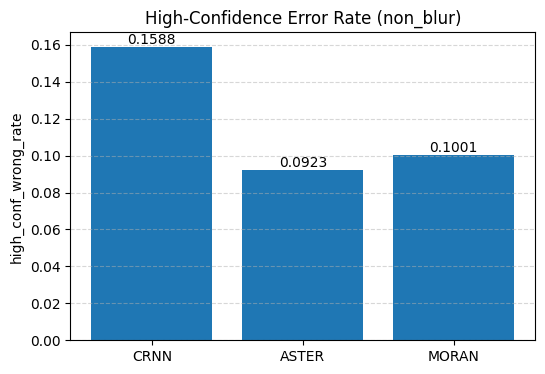

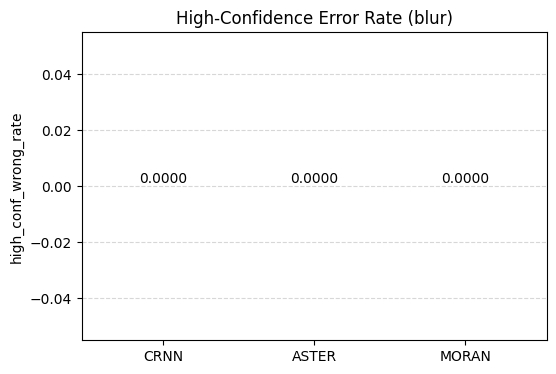

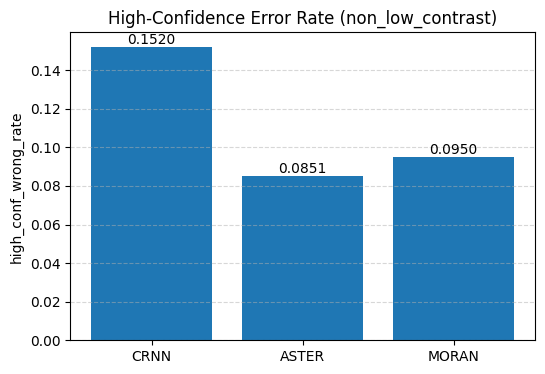

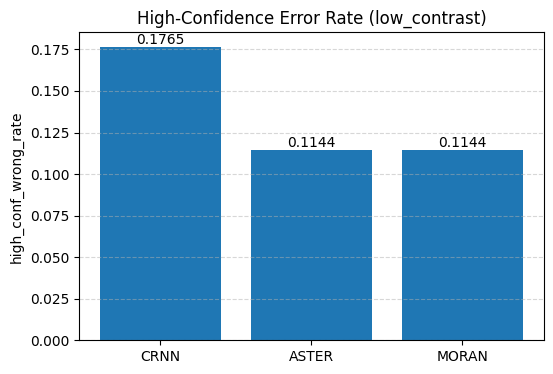

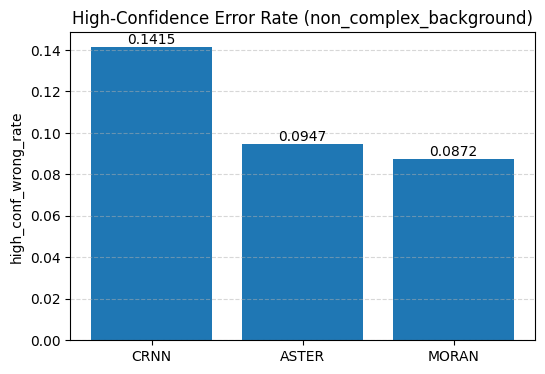

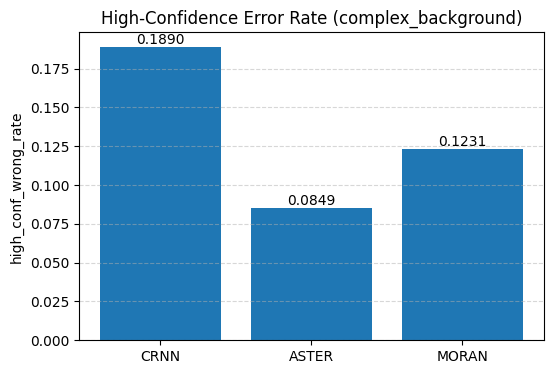

In [63]:
import matplotlib.pyplot as plt

for group in group_list:
    plot = type_summary_df[type_summary_df["group_col"] == group].copy()

    for sub_grp in plot["group_name"].unique():
        sub_df = plot[plot["group_name"] == sub_grp]

        plt.figure(figsize=(6, 4))
        bars = plt.bar(sub_df["model"], sub_df["high_conf_wrong_rate"])
        plt.title(f"High-Confidence Error Rate ({sub_grp})")
        plt.ylabel("high_conf_wrong_rate")
        plt.grid(axis = "y", linestyle = "--", alpha = 0.5)

        for b, v in zip(bars, sub_df["high_conf_wrong_rate"]):
            plt.text(
                b.get_x() + b.get_width() / 2,
                b.get_height(),
                f"{v :.4f}",
                ha = "center",
                va = "bottom"
            )

        plt.show()

In [64]:
import pandas as pd
import matplotlib.pyplot as plt


group_pair_map = {
    "is_blur": ("non_blur", "blur"),
    "is_low_contrast": ("non_low_contrast", "low_contrast"),
    "is_complex_background": ("non_complex_background", "complex_background")
}


group_title_map = {
    "is_blur": "Blur",
    "is_low_contrast": "Low Contrast",
    "is_complex_background": "Complex Background"
}

row = []


for group in group_list:
    easy_name, hard_name = group_pair_map[group]
    sub_df = type_summary_df[type_summary_df["group_col"] == group].copy()

    for model_name in ["CRNN", "ASTER", "MORAN"]:
        easy_row = sub_df[(sub_df["model"] == model_name) & (sub_df["group_name"] == easy_name)].iloc[0]

        hard_row = sub_df[(sub_df["model"] == model_name) & (sub_df["group_name"] == hard_name)].iloc[0]

        row.append({
            "model": model_name,
            "group_col": group,
            "easy_group": easy_name,
            "hard_group": hard_name,

            "easy_n": easy_row["n"],
            "hard_n": hard_row["n"],

            "easy_hcer": easy_row["high_conf_wrong_rate"],
            "hard_hcer": hard_row["high_conf_wrong_rate"],
            "delta_hcer": hard_row["high_conf_wrong_rate"] - easy_row["high_conf_wrong_rate"],

            "easy_ECE": easy_row["ECE"],
            "hard_ECE": hard_row["ECE"],
            "delta_ECE": hard_row["ECE"] - easy_row["ECE"],

            "easy_Brier": easy_row["Brier"],
            "hard_Brier": hard_row["Brier"],
            "delta_Brier": hard_row["Brier"] - easy_row["Brier"],
        })

trend_df = pd.DataFrame(row)
trend_df

,model,group_col,easy_group,hard_group,easy_n,hard_n,easy_hcer,hard_hcer,delta_hcer,easy_ECE,hard_ECE,delta_ECE,easy_Brier,hard_Brier,delta_Brier
0,CRNN,is_blur,non_blur,blur,1398,13,0.158798,0.000000,-0.158798,0.403141,0.287327,-0.115814,0.275440,0.107640,-0.167800
1,ASTER,is_blur,non_blur,blur,1398,13,0.092275,0.000000,-0.092275,0.289734,0.303893,0.014160,0.217780,0.128946,-0.088834
2,MORAN,is_blur,non_blur,blur,1398,13,0.100143,0.000000,-0.100143,0.340765,0.433139,0.092374,0.233671,0.205714,-0.027957
3,CRNN,is_low_contrast,non_low_contrast,low_contrast,1105,306,0.152036,0.176471,0.024434,0.390084,0.445372,0.055287,0.270114,0.287544,0.017431
4,ASTER,is_low_contrast,non_low_contrast,low_contrast,1105,306,0.085068,0.114379,0.029311,0.277292,0.335763,0.058471,0.209057,0.245506,0.036448
5,MORAN,is_low_contrast,non_low_contrast,low_contrast,1105,306,0.095023,0.114379,0.019356,0.327667,0.391991,0.064324,0.225417,0.262290,0.036872
6,CRNN,is_complex_background,non_complex_background,complex_background,940,471,0.141489,0.188960,0.047470,0.399779,0.406656,0.006878,0.258863,0.303891,0.045028
7,ASTER,is_complex_background,non_complex_background,complex_background,940,471,0.094681,0.084926,-0.009755,0.323416,0.223228,-0.100187,0.230449,0.190045,-0.040404
8,MORAN,is_complex_background,non_complex_background,complex_background,940,471,0.087234,0.123142,0.035908,0.364579,0.295789,-0.068790,0.236997,0.226264,-0.010733


In [65]:
max_case_df = trend_df[[
    "model", "group_col", "hard_group", "hard_n",
    "hard_hcer", "delta_hcer", "hard_ECE", "hard_Brier"
]].sort_values("hard_hcer", ascending = False).reset_index(drop = True)

max_case_df

,model,group_col,hard_group,hard_n,hard_hcer,delta_hcer,hard_ECE,hard_Brier
0,CRNN,is_complex_background,complex_background,471,0.188960,0.047470,0.406656,0.303891
1,CRNN,is_low_contrast,low_contrast,306,0.176471,0.024434,0.445372,0.287544
2,MORAN,is_complex_background,complex_background,471,0.123142,0.035908,0.295789,0.226264
3,ASTER,is_low_contrast,low_contrast,306,0.114379,0.029311,0.335763,0.245506
4,MORAN,is_low_contrast,low_contrast,306,0.114379,0.019356,0.391991,0.262290
5,ASTER,is_complex_background,complex_background,471,0.084926,-0.009755,0.223228,0.190045
6,CRNN,is_blur,blur,13,0.000000,-0.158798,0.287327,0.107640
7,ASTER,is_blur,blur,13,0.000000,-0.092275,0.303893,0.128946
8,MORAN,is_blur,blur,13,0.000000,-0.100143,0.433139,0.205714


In [66]:
largest_increase_df = trend_df[[
    "model", "group_col", "easy_group", "hard_group",
    "easy_hcer", "hard_hcer", "delta_hcer",
    "easy_n", "hard_n"
]].sort_values("delta_hcer", ascending = False).reset_index(drop = True)

largest_increase_df

,model,group_col,easy_group,hard_group,easy_hcer,hard_hcer,delta_hcer,easy_n,hard_n
0,CRNN,is_complex_background,non_complex_background,complex_background,0.141489,0.188960,0.047470,940,471
1,MORAN,is_complex_background,non_complex_background,complex_background,0.087234,0.123142,0.035908,940,471
2,ASTER,is_low_contrast,non_low_contrast,low_contrast,0.085068,0.114379,0.029311,1105,306
3,CRNN,is_low_contrast,non_low_contrast,low_contrast,0.152036,0.176471,0.024434,1105,306
4,MORAN,is_low_contrast,non_low_contrast,low_contrast,0.095023,0.114379,0.019356,1105,306
5,ASTER,is_complex_background,non_complex_background,complex_background,0.094681,0.084926,-0.009755,940,471
6,ASTER,is_blur,non_blur,blur,0.092275,0.000000,-0.092275,1398,13
7,MORAN,is_blur,non_blur,blur,0.100143,0.000000,-0.100143,1398,13
8,CRNN,is_blur,non_blur,blur,0.158798,0.000000,-0.158798,1398,13


In [67]:
worst_case_per_model = (
    max_case_df.sort_values(["model", "hard_hcer"], ascending = [True, False])
    .groupby("model", as_index = False)
    .first()
)

worst_case_per_model

,model,group_col,hard_group,hard_n,hard_hcer,delta_hcer,hard_ECE,hard_Brier
0,ASTER,is_low_contrast,low_contrast,306,0.114379,0.029311,0.335763,0.245506
1,CRNN,is_complex_background,complex_background,471,0.188960,0.047470,0.406656,0.303891
2,MORAN,is_complex_background,complex_background,471,0.123142,0.035908,0.295789,0.226264


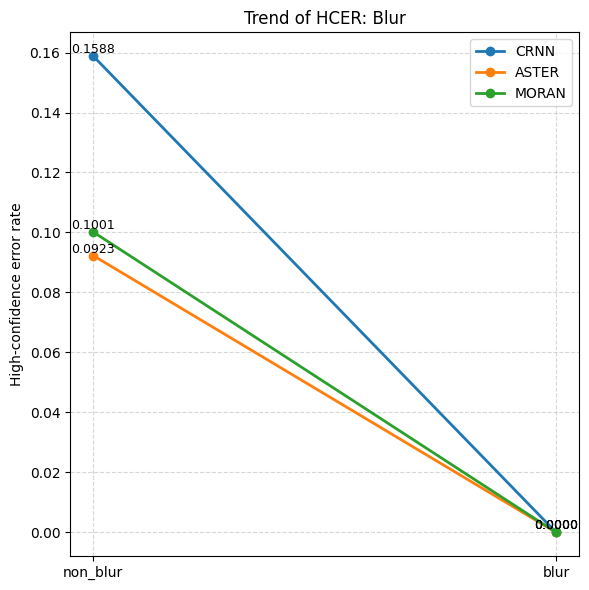

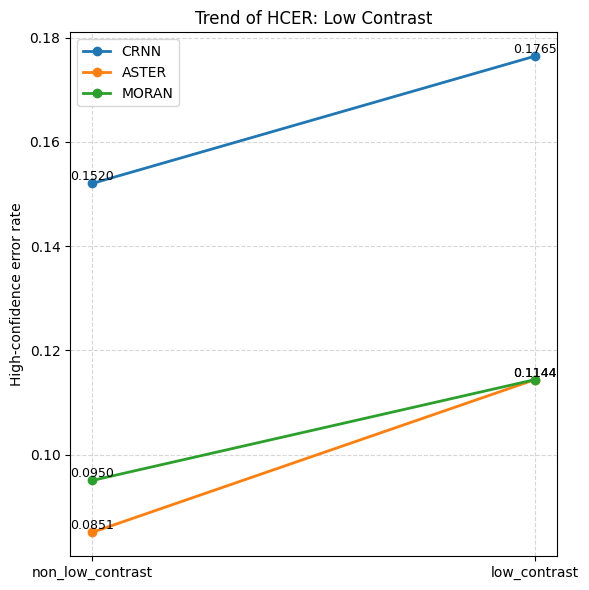

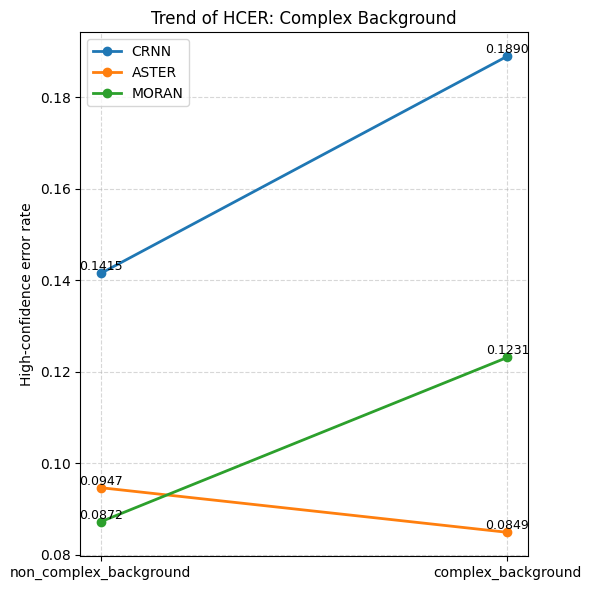

In [68]:
for group in group_list:
    sub_df = trend_df[trend_df["group_col"] == group].copy()

    plt.figure(figsize = (6, 6))

    for _, row in sub_df.iterrows():
        xs = [0, 1]
        ys = [row["easy_hcer"], row["hard_hcer"]]

        plt.plot(xs, ys, marker = "o", linewidth = 2, label = row["model"])

        plt.text(0, row["easy_hcer"], f'{row["easy_hcer"]:.4f}', ha = "center", va = "bottom", fontsize = 9)
        plt.text(1, row["hard_hcer"], f'{row["hard_hcer"]:.4f}', ha = "center", va = "bottom", fontsize = 9)

    plt.xticks([0, 1], [sub_df["easy_group"].iloc[0], sub_df["hard_group"].iloc[0]])
    plt.ylabel("High-confidence error rate")
    plt.title(f"Trend of HCER: {group_title_map[group]}")
    plt.grid(True, linestyle = "--", alpha = 0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Calibration

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

In [70]:
# crnn
import utils
import dataset
import models.crnn as crnn
from PIL import Image
from scipy.stats import gmean

# defining CRNN parameters
# plus one for CTC
apt = "0123456789abcdefghijklmnopqrstuvwxyz"
n = len(apt) + 1
model = crnn.CRNN(32, 1, n, 256)

# load crnn weight
crnn_w = torch.load(
    CRNN_REPO / "data" / "crnn.pth",
    map_location = "cpu",
    weights_only = False
)
model.load_state_dict(crnn_w)
model = model.to(device)
model.eval()

print("CRNN loaded successful on", device)

CRNN loaded successful on cuda


In [71]:
df_train2_crnn = df[df["split"] == "train2"].copy()
results = df_train2_crnn["lr_path"].apply(predict_crnn)
df_train2_crnn[["pred_text", "confidence", "raw_text"]] = pd.DataFrame(
    results.tolist(),
    index = df_train2_crnn.index
)

df_train2_crnn["label_n"] = df_train2_crnn["label"].apply(normalize_text)
df_train2_crnn["pred_n"] = df_train2_crnn["pred_text"].apply(normalize_text)
df_train2_crnn["correct_n"] = (
    df_train2_crnn["label_n"] == df_train2_crnn["pred_n"]
).astype(int)

In [72]:
# ASTER
os.chdir(ASTER_REPO)
sys.argv = [sys.argv[0], "--with_lstm"]

data_info = DataInfo("ALLCASES_SYMBOLS")

aster = ModelBuilder(
    arch = "ResNet_ASTER",
    rec_num_classes = data_info.rec_num_classes,
    sDim = 512,
    attDim = 512,
    max_len_labels = 100,
    eos = data_info.char2id[data_info.EOS],
    STN_ON = True
)

aster_w = torch.load(
    ASTER_REPO  / "data" / "demo.pth", 
    map_location = "cpu", 
    weights_only = False)

# depending on checkpoint format:
if "state_dict" in aster_w:
    aster.load_state_dict(aster_w["state_dict"])
else:
    aster.load_state_dict(aster_w)

aster = aster.to(device)
aster.eval()

print("ASTER loaded successfully on", device)

TPS_INPUTSIZE = (32, 64)


def image_process(path, H = 32, W = 100):
    # read image, resize, convert to tensor, normalize to [-1, 1]
    img = Image.open(path).convert("RGB")
    img = img.resize((W, H), Image.BILINEAR)
    img = transforms.ToTensor()(img)
    img.sub_(0.5).div_(0.5)
    return img


@torch.no_grad()
def sample_cuda_safe(self, x):
    # keep all new tensor on the same device as encoder feature
    batch_size = x.size(0)
    dev = x.device
    state = torch.zeros(1, batch_size, self.sDim, device = dev)

    pred_idx = []
    max_p = []

    for i in range(self.max_len_labels):
        # first step uses BOS token
        if i == 0:
            y_prev = torch.full((batch_size,), self.num_classes, dtype = torch.long, device = dev)
        else:
            y_prev = pred.long().to(dev)

        output, state = self.decoder(x, state, y_prev)
        p = F.softmax(output, dim = 1)
        p_max, pred = p.max(1)

        pred_idx.append(pred.unsqueeze(1))
        max_p.append(p_max.unsqueeze(1))

    pred_idx = torch.cat(pred_idx, dim = 1)
    max_p = torch.cat(max_p, dim = 1)

    return pred_idx, max_p


# patch decoder with CUDA safe greedy decoding
aster.decoder.sample = types.MethodType(sample_cuda_safe, aster.decoder)


@torch.no_grad()
def aster_forward_n(model, img):
    x = img

    # rectify image with STN / TPS before recognition
    if model.STN_ON:
        stn_input = F.interpolate(x, TPS_INPUTSIZE,mode = "bilinear", align_corners = True)
        _, ctrl_point = model.stn_head(stn_input)
        x, _ = model.tps(x, ctrl_point)

    # extract visual sequence feature
    encoder_feat = model.encoder(x).contiguous()

    # greedy decode on encoder feature
    pred_idx, max_p = model.decoder.sample(encoder_feat)

    return pred_idx, max_p


def predict_aster(path):
    img = image_process(path, H = 32, W = 100)
    img = img.unsqueeze(0).to(device)

    eos_id = data_info.char2id[data_info.EOS]
    pad_id = data_info.char2id[data_info.PADDING]
    unk_id = data_info.char2id[data_info.UNKNOWN]

    with torch.no_grad():
        pred_idx, max_p = aster_forward_n(aster, img)
        
        pred_idx = pred_idx[0].detach().cpu().tolist()
        p_list = max_p[0].detach().cpu().tolist()

        char = []
        raw_token = []
        result_p = []

        for idx, p in zip(pred_idx, p_list):
            idx = int(idx)
            ch = data_info.id2char.get(idx, "")

            raw_token.append(ch)

            # stop at EOS
            if idx == eos_id:
                break

            # skip padding
            if idx == pad_id:
                continue

            # map unknown token to '?'
            if idx == unk_id:
                char.append("?")
            else:
                char.append(ch)

            result_p.append(float(p))

        pred_text = "".join(char)
        raw_text = " | ".join(raw_token)

        pred_chars = list(pred_text)
        if len(pred_chars) != len(result_p):
            min_len = min(len(pred_chars), len(result_p))
            pred_chars = pred_chars[:min_len]
            result_p = result_p[:min_len]

        filtered_p = []
        for ch, p in zip(pred_chars, result_p):
            ch = str(ch).lower()
            if re.fullmatch(r"[a-z0-9]", ch):
                filtered_p.append(float(p))
        result_p = filtered_p 
        
        # calculate confidence by using geometric mean
        if result_p:
            conf = float(gmean(np.clip(result_p, 1e-12, 1.0)))
        else:
            conf = 0.0

    return pred_text, conf, raw_text

ASTER loaded successfully on cuda


In [73]:

# df_train2_aster["correct"] = (
#     df_train2_aster["pred_text"] == df_train2_aster["label"]
# ).astype(int)

# df_train2_aster.head()

In [74]:
df_train2_aster = df[df["split"] == "train2"].copy()
results = df_train2_aster["lr_path"].apply(predict_aster)
df_train2_aster[["pred_text", "confidence", "raw_text"]] = pd.DataFrame(
    results.tolist(),
    index=df_train2_aster.index
)

df_train2_aster["label_n"] = df_train2_aster["label"].apply(normalize_text)
df_train2_aster["pred_n"]  = df_train2_aster["pred_text"].apply(normalize_text)

df_train2_aster["correct_n"] = (
    df_train2_aster["label_n"] == df_train2_aster["pred_n"]
).astype(int)

C:\Users\Eric Zhang\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


In [75]:
from collections import OrderedDict

import os
import sys
import importlib
from collections import OrderedDict

os.chdir(MORAN_REPO)

if MORAN_REPO not in sys.path:
    sys.path.insert(0, MORAN_REPO)

if "models" in sys.modules:
    del sys.modules["models"]

moran_utils = importlib.import_module("tools.utils")
moran_dataset = importlib.import_module("tools.dataset")
MORAN = importlib.import_module("models.moran").MORAN

apt = "0:1:2:3:4:5:6:7:8:9:a:b:c:d:e:f:g:h:i:j:k:l:m:n:o:p:q:r:s:t:u:v:w:x:y:z:$"
n = len(apt.split(":"))

moran_model = MORAN(1, n, 256, 32, 100, BidirDecoder = True, CUDA = True)

state_dict = torch.load(
    MORAN_REPO / "demo" / "demo.pth",
    map_location = "cpu",
    weights_only = False
)

state_dict_rename = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")
    state_dict_rename[name] = v

moran_model.load_state_dict(state_dict_rename)
moran_model = moran_model.to(device)
moran_model.eval()

for p in moran_model.parameters():
    p.requires_grad = False


moran_converter = moran_utils.strLabelConverterForAttention(apt, ":")
normalize = moran_dataset.resizeNormalize((100, 32))

print("MORAN loaded on", device)

@torch.no_grad()
def predict_moran(path, max_iter = 20):
    # into grayscale and on gpu
    img = Image.open(path).convert("L")
    img = normalize(img)
    img = img.view(1, *img.size()).to(device)

    text = torch.LongTensor(1 * 5)
    length = torch.IntTensor(1)

    t, l = moran_converter.encode("0" * max_iter)
    utils.loadData(text, t)
    utils.loadData(length, l)

    text = text.to(device)
    length = length.to(device)

    # debug = False for normal inference
    pred = moran_model(img, length, text, text, test = True, debug = False)

    # test = True and BidirDecoder = True -> (preds_ltr, preds_rtl)
    pred_ltr, pred_rtl = pred

    log = pred_ltr
    p = F.softmax(log, dim = 1)
    max_p, max_idx = p.max(1)

    raw_text = moran_converter.decode(max_idx.data, length.data)
    pred_text = raw_text.strip().split("$")[0]

    raw_seq = raw_text.strip()
    eos_pos = raw_seq.find("$")

    if eos_pos == -1:
        result_p = max_p[ : len(raw_seq)]
    else:
        result_p = max_p[ : eos_pos + 1]

    result_p = result_p.detach().cpu().numpy()

    pred_chars = list(pred_text)
    if len(pred_chars) != len(result_p):
        min_len = min(len(pred_chars), len(result_p))
        pred_chars = pred_chars[:min_len]
        result_p = result_p[:min_len]
        
    filtered_p = []
    for ch, p in zip(pred_chars, result_p):
        ch = str(ch).lower()
        if re.fullmatch(r"[a-z0-9]", ch):
            filtered_p.append(float(p))
    result_p = filtered_p 

    # calculate confidence by using geometric mean
    if len(result_p) > 0:
        conf = float(gmean(np.clip(result_p, 1e-12, 1.0)))
    else:
        conf = 0.0

    return pred_text, conf, raw_text

MORAN loaded on cuda


C:\Users\Eric Zhang\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
E:\TT_exported\MORAN_v2-master\models\asrn_res.py:234: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  nn.init.kaiming_normal(m.weight, mode='fan_out', a=0)
E:\TT_exported\MORAN_v2-master\models\asrn_res.py:236: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  nn.init.constant(m.weight, 1)
E:\TT_exported\MORAN_v2-master\models\asrn_res.py:237: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  nn.init.constant(m.bias, 0)


In [76]:
df = pd.read_csv(r"E:\TT_exported\all_labels.csv")
df_train2_moran = df[df["split"] ==  "train2"].copy()

results = df_train2_moran["lr_path"].apply(predict_moran)

df_train2_moran[["pred_text", "confidence", "raw_text"]] = pd.DataFrame(
    results.tolist(),
    index=df_train2_moran.index
)


df_train2_moran.head()

df_train2_moran["label_n"] = df_train2_moran["label"].apply(normalize_text)
df_train2_moran["pred_n"]  = df_train2_moran["pred_text"].apply(normalize_text)

df_train2_moran["correct_n"] = (
    df_train2_moran["label_n"] == df_train2_moran["pred_n"]
).astype(int)

E:\TT_exported\MORAN_v2-master\models\morn.py:59: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x_small = nn.functional.upsample(x, size=(self.targetH, self.targetW), mode='bilinear')
C:\Users\Eric Zhang\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


In [77]:
def fit_logistic_calibrator(df_cal, conf_col = "confidence", correct_n_col = "correct_n"):
    X = df_cal[[conf_col]].copy()
    X[conf_col] = X[conf_col].clip(1e-6, 1 - 1e-6)

    y = df_cal[correct_n_col].astype(int).values

    calibrator = LogisticRegression(solver = "lbfgs")
    calibrator.fit(X, y)

    return calibrator
    
def apply_logistic_calibrator(df_in, calibrator, conf_col = "confidence", out_col = "confidence_calibrated"):
    df_out = df_in.copy()

    X = df_out[[conf_col]].copy()
    X[conf_col] = X[conf_col].clip(1e-6, 1 - 1e-6)

    df_out[out_col] = calibrator.predict_proba(X)[:, 1]
    return df_out

In [78]:
cal_crnn = fit_logistic_calibrator(df_train2_crnn, conf_col = "confidence", correct_n_col =  "correct_n")
cal_aster = fit_logistic_calibrator(df_train2_aster, conf_col = "confidence", correct_n_col = "correct_n")
cal_moran = fit_logistic_calibrator(df_train2_moran, conf_col = "confidence", correct_n_col = "correct_n")

In [79]:
df_test_medium_cal = apply_logistic_calibrator(
    df_test_medium, cal_crnn,
    conf_col = "confidence", out_col = "confidence_calibrated"
)

df_test_medium_aster_cal = apply_logistic_calibrator(
    df_test_medium_aster, cal_aster,
    conf_col = "confidence", out_col = "confidence_calibrated"
)

df_test_medium_moran_cal = apply_logistic_calibrator(
    df_test_medium_moran, cal_moran,
    conf_col = "confidence", out_col = "confidence_calibrated"
)

In [80]:
def summarize_calibration(df_in, model_name, setting_name,
                          correct_n_col = "correct_n",
                          conf_col = "confidence",
                          conf_thr = 0.8):
    
    table, ece, brier = calibration_table(
        y_true = df_in[correct_n_col],
        y_p = df_in[conf_col],
        n_bin = 10
    )

    return {
        "model": model_name,
        "setting": setting_name,
        "n": len(df_in),
        "word_acc": df_in[correct_n_col].mean(),
        "avg_conf": df_in[conf_col].mean(),
        "ECE": ece,
        "Brier": brier,
        "high_conf_wrong_rate": (
            (df_in[correct_n_col] == 0) & (df_in[conf_col] >= conf_thr)
        ).mean(),
        "high_conf_wrong_n": (
            (df_in[correct_n_col] == 0) & (df_in[conf_col] >= conf_thr)
        ).sum()
    }

In [81]:
row = []

# CRNN
row.append(summarize_calibration(
    df_test_medium, "CRNN", "Before",
    correct_n_col = "correct_n", conf_col = "confidence"
))
row.append(summarize_calibration(
    df_test_medium_cal, "CRNN", "After",
    correct_n_col = "correct_n", conf_col = "confidence_calibrated"
))

# ASTER
row.append(summarize_calibration(
    df_test_medium_aster, "ASTER", "Before",
    correct_n_col = "correct_n", conf_col = "confidence"
))
row.append(summarize_calibration(
    df_test_medium_aster_cal, "ASTER", "After",
    correct_n_col = "correct_n", conf_col = "confidence_calibrated"
))

# MORAN
row.append(summarize_calibration(
    df_test_medium_moran, "MORAN", "Before",
    correct_n_col = "correct_n", conf_col = "confidence"
))
row.append(summarize_calibration(
    df_test_medium_moran_cal, "MORAN", "After",
    correct_n_col = "correct_n", conf_col = "confidence_calibrated"
))

compare_df = pd.DataFrame(row)
compare_df

,model,setting,n,word_acc,avg_conf,ECE,Brier,high_conf_wrong_rate,high_conf_wrong_n
0,CRNN,Before,1411,0.205528,0.607602,0.402074,0.273894,0.157335,222
1,CRNN,After,1411,0.205528,0.262412,0.079679,0.095541,0.000000,0
2,ASTER,Before,1411,0.411056,0.699611,0.289864,0.216962,0.091425,129
3,ASTER,After,1411,0.411056,0.456587,0.068176,0.107561,0.031892,45
4,MORAN,Before,1411,0.366407,0.708023,0.341616,0.233414,0.099220,140
5,MORAN,After,1411,0.366407,0.403201,0.069245,0.086128,0.025514,36


In [82]:
def plot_before_after(compare_df, metric, title):
    plot = compare_df.copy()

    model_list = ["CRNN", "ASTER", "MORAN"]
    x = np.arange(len(model_list))
    width = 0.35

    before_val = [
        plot[(plot["model"] == m) & (plot["setting"] == "Before")][metric].values[0]
        for m in model_list
    ]
    
    after_val = [
        plot[(plot["model"] == m) & (plot["setting"] == "After")][metric].values[0]
        for m in model_list
    ]

    plt.figure(figsize = (7, 4))
    bars1 = plt.bar(x - width/2, before_val, width, label = "Before")
    bars2 = plt.bar(x + width/2, after_val, width, label = "After")

    plt.xticks(x, model_list)
    plt.ylabel(metric)
    plt.title(title)
    plt.grid(axis = "y", linestyle = "--", alpha = 0.5)
    plt.legend()

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                h,
                f"{h:.4f}",
                ha = "center",
                va = "bottom",
                fontsize = 9
            )

    plt.tight_layout()
    plt.show()

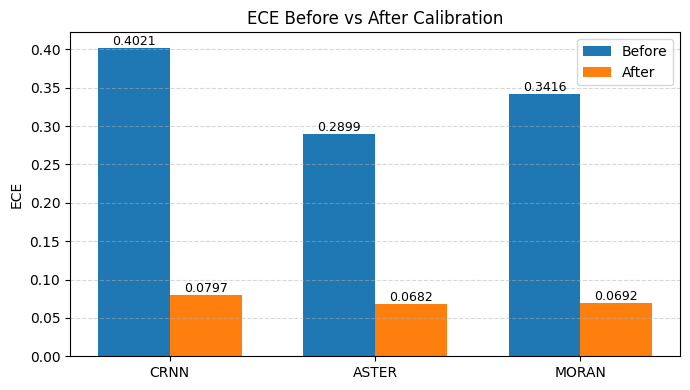

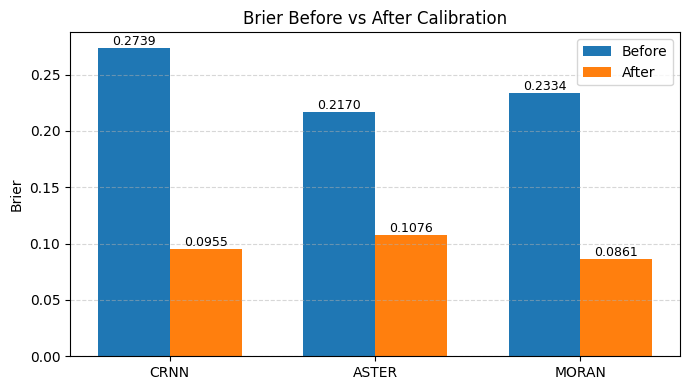

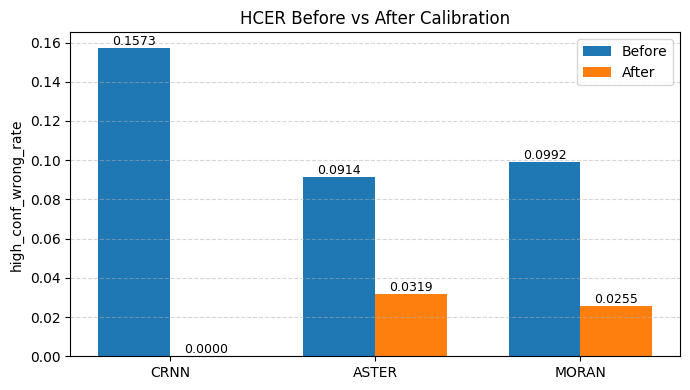

In [83]:
plot_before_after(compare_df, "ECE", "ECE Before vs After Calibration")
plot_before_after(compare_df, "Brier", "Brier Before vs After Calibration")
plot_before_after(compare_df, "high_conf_wrong_rate", "HCER Before vs After Calibration")

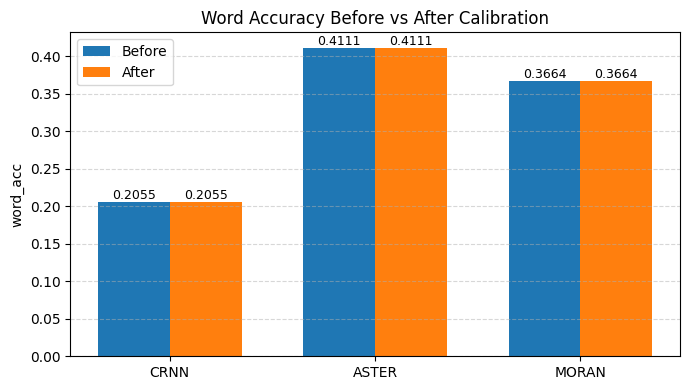

In [84]:
plot_before_after(compare_df, "word_acc", "Word Accuracy Before vs After Calibration")